In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
import pandas as pd
import numpy as np


df = pd.read_excel("/content/personal_male.xlsx")


print(df.isna().sum())


df['bowlingStyle'] = df['bowlingStyle'].fillna('Unknown')
df = df.dropna(subset=['battingStyle'])


df['dob'] = pd.to_datetime(df['dob'], dayfirst=True)

df['country'] = df['country'].astype('category')
df['birthPlace'] = df['birthPlace'].astype('category')
df['nationalTeam'] = df['nationalTeam'].astype('category')
df['teams'] = df['teams'].astype('category')
df['battingStyle'] = df['battingStyle'].astype('category')
df['bowlingStyle'] = df['bowlingStyle'].astype('category')


df = df.drop_duplicates()


df['birthYear'] = df['dob'].dt.year
current_year = pd.Timestamp.now().year
df['age'] = current_year - df['birthYear']


print(df.info())


df.to_csv('project_data_clean.csv', index=False)

name              0
fullName          0
dob               0
country           0
birthPlace        0
nationalTeam     68
teams             0
battingStyle      6
bowlingStyle    481
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 3850 entries, 0 to 3855
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   name          3850 non-null   object        
 1   fullName      3850 non-null   object        
 2   dob           3850 non-null   datetime64[ns]
 3   country       3850 non-null   category      
 4   birthPlace    3850 non-null   category      
 5   nationalTeam  3784 non-null   category      
 6   teams         3850 non-null   category      
 7   battingStyle  3850 non-null   category      
 8   bowlingStyle  3850 non-null   category      
 9   birthYear     3850 non-null   int32         
 10  age           3850 non-null   int32         
dtypes: category(6), datetime64[ns](1), int32(2), objec

Context & Bias: Look at the specific rows with missing values. If you were to drop these rows, would you be systematically excluding a specific subgroup (e.g., a specific year, region, or demographic)? Explain how this might bias your analysis.
The missing values mainly appear in the nationalTeam, battingStyle, and bowlingStyle columns. Dropping all rows with missing bowlingStyle would remove a large number of players who may not bowl, which could bias the dataset by overrepresenting bowlers. Therefore, removing those rows entirely would distort the representation of player roles.

Strategy Justification: For the columns with missing data, explain why your chosen strategy (dropping vs. imputing) is the safest approach for your specific research question.
Example: "I am dropping 'Budget' because imputing an average would hide the distinction between indie and blockbuster films, which is central to my thesis."
For the bowlingStyle column, I will fill missing values with a placeholder such as "Unknown" because the absence of a bowling style may indicate that the player is not primarily a bowler. For battingStyle, only a small number of values are missing, so dropping those rows is reasonable and will not significantly affect the dataset. This approach preserves as much useful information as possible while maintaining data quality.



Final Reflection: Double click here to edit.

Trade-offs: Compare your raw row count to your final row count. Explain why the benefits of having "clean" data outweigh the loss of sample size in your specific case.
The raw dataset contained slightly more records before cleaning, but only a small number of rows were removed due to missing battingStyle. Keeping rows with incomplete critical information could reduce analysis quality and introduce ambiguity. By cleaning the dataset and ensuring consistent values, the overall reliability and interpretability of the analysis improves. The small reduction in sample size does not significantly impact representativeness, while the benefit of having structured, usable data outweighs the minimal loss of observations.

Limitations: Every data cleaning decision involves compromise. Describe one specific limitation your cleaning strategy has introduced. (e.g., "By removing outliers, I may be ignoring extreme but valid user behaviors.")
One limitation of this cleaning strategy is that replacing missing bowlingStyle values with "Unknown" assumes that missing data reflects non-bowlers or unspecified roles. This may oversimplify real player characteristics and could reduce nuance in future analysis. Additionally, dropping rows with missing battingStyle may exclude a few valid players, which slightly reduces dataset completeness.


In [26]:
df.head()

,name,fullName,dob,country,birthPlace,nationalTeam,teams,battingStyle,bowlingStyle,birthYear,age
0,Aakash Chopra,Aakash Shyamlal Chopra,1977-09-19,India,"Agra, Uttar Pradesh, India",India,"India, Kolkata Knight Riders",Right-hand bat,Right-arm medium,1977,49
1,Aamer Hameed,Aamer Hameed,1954-10-18,Pakistan,"Lahore, Punjab, Pakistan",Pakistan,Pakistan,Right-hand bat,Right-arm medium-fast,1954,72
2,Aamer Hanif,Aamer Hanif,1967-04-10,Pakistan,"Karachi, Sind, Pakistan",Pakistan,Pakistan,Right-hand bat,Right-arm medium,1967,59
3,Aamer Malik,Aamer Malik,1963-03-01,Pakistan,"Mandi Bahauddin, Punjab, Pakistan",Pakistan,Pakistan,Right-hand bat,Right-arm fast-medium,1963,63
4,Aamer Nazir,Aamer Nazir,1971-02-01,Pakistan,"Lahore, Punjab, Pakistan",Pakistan,Pakistan,Right-hand bat,Right-arm fast-medium,1971,55


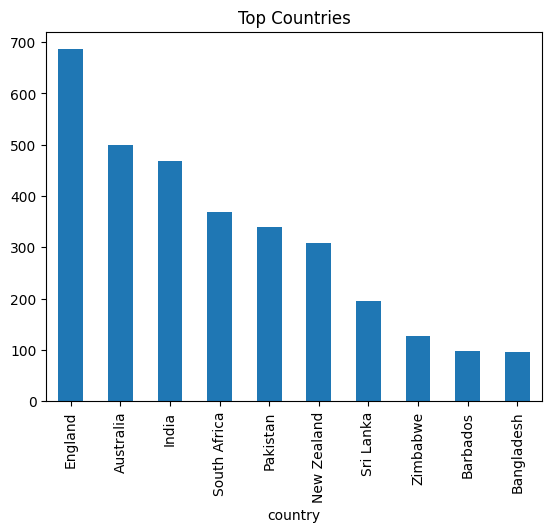

In [30]:
plt.figure()
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.savefig("figure2.png")
plt.show()

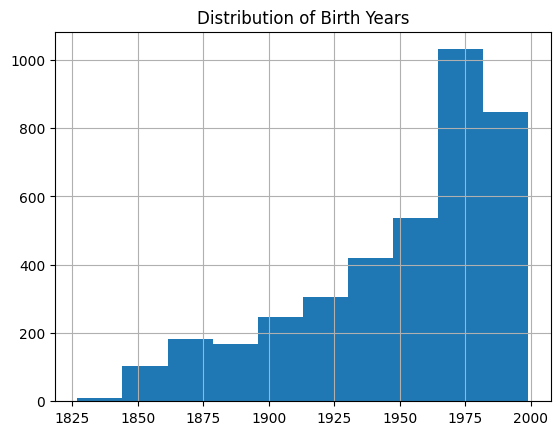

In [28]:
plt.figure()
df['dob'].dt.year.hist()
plt.title("Distribution of Birth Years")
plt.savefig("figure1.png")
plt.show()

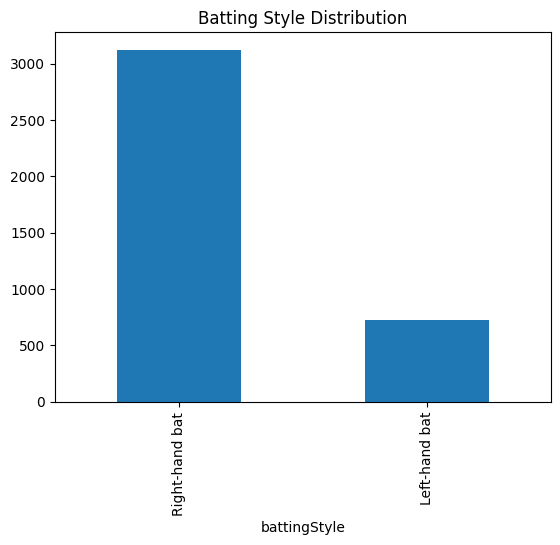

In [29]:
plt.figure()
df['battingStyle'].value_counts().plot(kind='bar')
plt.title("Batting Style Distribution")
plt.savefig("figure3.png")
plt.show()

## Data Cleaning
Handled missing values and converted categorical variables.

## Analysis
Analyzed player demographics and playing styles.

## Results
Observed trends in player distribution by country and batting style.